# WS02 — MNIST Digit Classification with Softmax Regression
###  Complete Solved Version

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

## 1. Softmax Function

In [3]:
def softmax(z):
    """
    Compute softmax probabilities.
    Uses numerical stabilization by subtracting max per row.
    """
    z_stable = z - np.max(z, axis=1, keepdims=True)  # subtract max for stability
    exp_z = np.exp(z_stable)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

# --- Test ---
z_test = np.array([[2.0, 1.0, 0.1], [1.0, 1.0, 1.0]])
softmax_output = softmax(z_test)
row_sums = np.sum(softmax_output, axis=1)
assert np.allclose(row_sums, 1), f"Test failed: Row sums are {row_sums}"
print("Softmax function passed the test case!")

Softmax function passed the test case!


## 2. Prediction Function

In [4]:
def predict_softmax(X, W, b):
    """Predict class labels using the trained softmax model."""
    predicted_classes = np.argmax(softmax(np.dot(X, W) + b), axis=1)
    return predicted_classes

# --- Test ---
X_test = np.array([[0.2, 0.8], [0.5, 0.5], [0.9, 0.1]])
W_test = np.array([[0.4, 0.2, 0.1], [0.3, 0.7, 0.5]])
b_test = np.array([0.1, 0.2, 0.3])
y_pred_test = predict_softmax(X_test, W_test, b_test)
assert y_pred_test.shape == (3,), f"Expected shape (3,), got {y_pred_test.shape}"
print("Predicted class labels:", y_pred_test)

Predicted class labels: [1 1 0]


## 3. Loss Function (Cross-Entropy, single sample)

In [5]:
def loss_softmax(y_pred, y):
    """Compute cross-entropy loss for a single sample."""
    loss = -np.sum(y * np.log(y_pred + 1e-15)) / y_pred.shape[0]
    return loss

# --- Test ---
y_true_correct   = np.array([[1,0,0],[0,1,0],[0,0,1]])
y_pred_correct   = np.array([[0.9,0.05,0.05],[0.1,0.85,0.05],[0.05,0.1,0.85]])
y_pred_incorrect = np.array([[0.05,0.05,0.9],[0.1,0.05,0.85],[0.85,0.1,0.05]])
loss_correct   = loss_softmax(y_pred_correct,   y_true_correct)
loss_incorrect = loss_softmax(y_pred_incorrect, y_true_correct)
assert loss_correct < loss_incorrect
print(f"Cross-Entropy Loss (Correct Predictions):   {loss_correct:.4f}")
print(f"Cross-Entropy Loss (Incorrect Predictions): {loss_incorrect:.4f}")

Cross-Entropy Loss (Correct Predictions):   0.1435
Cross-Entropy Loss (Incorrect Predictions): 2.9957


## 4. Cost Function (Average over all samples)

In [6]:
def cost_softmax(X, y, W, b):
    """Compute average softmax cross-entropy loss over all samples."""
    n = X.shape[0]                              # number of samples
    z = np.dot(X, W) + b                        # logits
    y_pred = softmax(z)                         # probabilities
    total_loss = -np.sum(y * np.log(y_pred + 1e-15))
    return total_loss / n

# --- Test ---
X_correct   = np.array([[1.0,0.0],[0.0,1.0]])
y_correct   = np.array([[1,0],[0,1]])
W_correct   = np.array([[5.0,-2.0],[-3.0,5.0]])
b_correct   = np.array([0.1,0.1])
X_incorrect = np.array([[0.1,0.9],[0.8,0.2]])
y_incorrect = np.array([[1,0],[0,1]])
W_incorrect = np.array([[0.1,2.0],[1.5,0.3]])
b_incorrect = np.array([0.5,0.6])
cost_correct   = cost_softmax(X_correct,   y_correct,   W_correct,   b_correct)
cost_incorrect = cost_softmax(X_incorrect, y_incorrect, W_incorrect, b_incorrect)
assert cost_incorrect > cost_correct
print("Cost for correct prediction:",   cost_correct)
print("Cost for incorrect prediction:", cost_incorrect)
print("Test passed!")

Cost for correct prediction: 0.0006234364133339325
Cost for incorrect prediction: 0.2993086135944598
Test passed!


## 5. Compute Gradients

In [7]:
def compute_gradient_softmax(X, y, W, b):
    """Compute gradients of cost w.r.t. weights and biases."""
    n = X.shape[0]
    z = np.dot(X, W) + b
    y_pred = softmax(z)
    grad_W = np.dot(X.T, (y_pred - y)) / n   # shape (d, c)
    grad_b = np.sum(y_pred - y, axis=0) / n  # shape (c,)
    return grad_W, grad_b

# --- Test ---
X_test = np.array([[0.2,0.8],[0.5,0.5],[0.9,0.1]])
y_test = np.array([[1,0,0],[0,1,0],[0,0,1]])
W_test = np.array([[0.4,0.2,0.1],[0.3,0.7,0.5]])
b_test = np.array([0.1,0.2,0.3])
grad_W, grad_b = compute_gradient_softmax(X_test, y_test, W_test, b_test)
z_manual  = np.dot(X_test, W_test) + b_test
y_pred_m  = softmax(z_manual)
grad_W_manual = np.dot(X_test.T, (y_pred_m - y_test)) / X_test.shape[0]
grad_b_manual = np.sum(y_pred_m - y_test, axis=0) / X_test.shape[0]
assert np.allclose(grad_W, grad_W_manual)
assert np.allclose(grad_b, grad_b_manual)
print("Gradient w.r.t. W:", grad_W)
print("Gradient w.r.t. b:", grad_b)
print("Test passed!")

Gradient w.r.t. W: [[ 0.1031051   0.01805685 -0.12116196]
 [-0.13600547  0.00679023  0.12921524]]
Gradient w.r.t. b: [-0.03290036  0.02484708  0.00805328]
Test passed!


## 6. Gradient Descent

In [8]:
def gradient_descent_softmax(X, y, W, b, alpha, n_iter, show_cost=False):
    """Optimize weights and biases using gradient descent."""
    cost_history = []
    for i in range(n_iter):
        grad_W, grad_b = compute_gradient_softmax(X, y, W, b)
        W = W - alpha * grad_W   # update weights
        b = b - alpha * grad_b   # update biases
        cost = cost_softmax(X, y, W, b)
        cost_history.append(cost)
        if show_cost and (i % 100 == 0 or i == n_iter - 1):
            print(f"Iteration {i:4d}: Cost = {cost:.6f}")
    return W, b, cost_history

## 7. Load & Prepare MNIST Dataset

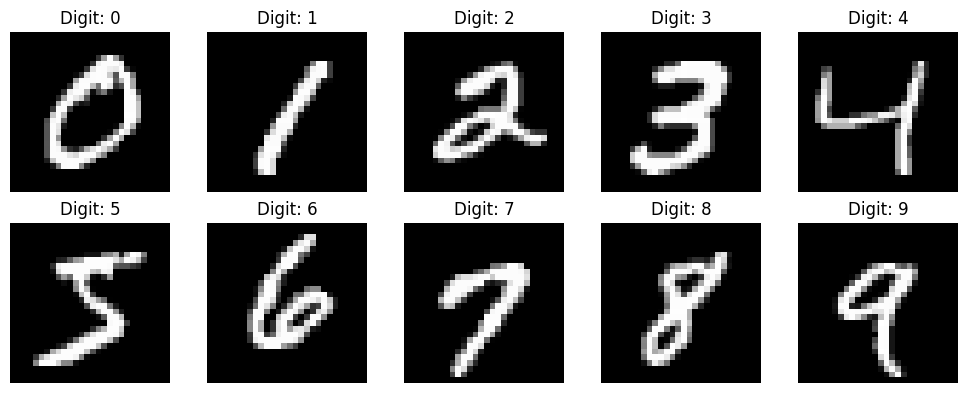

Dimensions matched. Move forward!


In [9]:
def plot_sample_images(X, y):
    plt.figure(figsize=(10, 4))
    for i, digit in enumerate(np.unique(y)):
        index = np.where(y == digit)[0][0]
        image = X[index].reshape(28, 28)
        plt.subplot(2, 5, i + 1)
        plt.imshow(image, cmap='gray')
        plt.title(f"Digit: {digit}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

def load_and_prepare_mnist(csv_file, test_size=0.2, random_state=42):
    df = pd.read_csv(csv_file)
    y = df.iloc[:, 0].values
    X = df.iloc[:, 1:].values
    X = X / 255.0
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)
    plot_sample_images(X, y)
    return X_train, X_test, y_train, y_test

csv_file_path = "/content/drive/MyDrive/Ai and Machine Learning/Week2/mnist_dataset.csv"
X_train, X_test, y_train, y_test = load_and_prepare_mnist(csv_file_path)
assert len(X_train) == len(y_train)
print("Dimensions matched. Move forward!")

## 8. Train the Model

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Training data shape: (48000, 784)
Test data shape:     (12000, 784)
Iteration    0: Cost = 2.193884
Iteration  100: Cost = 0.607120
Iteration  200: Cost = 0.489539
Iteration  300: Cost = 0.440953
Iteration  400: Cost = 0.412873
Iteration  500: Cost = 0.394000
Iteration  600: Cost = 0.380171
Iteration  700: Cost = 0.369458
Iteration  800: Cost = 0.360828
Iteration  900: Cost = 0.353673
Iteration  999: Cost = 0.347666


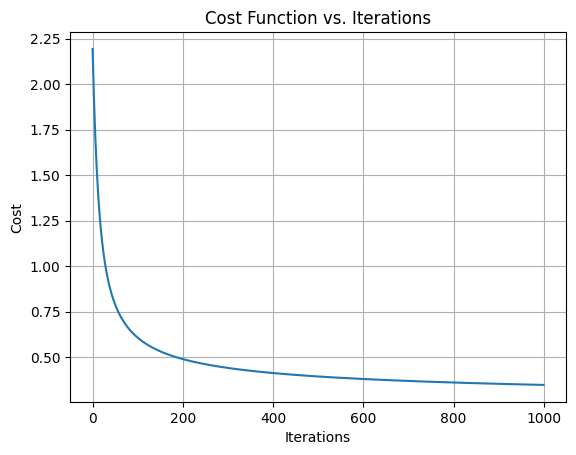

In [11]:
print(f"Training data shape: {X_train.shape}")
print(f"Test data shape:     {X_test.shape}")

# One-hot encode labels
if len(y_train.shape) == 1:
    encoder = OneHotEncoder(sparse_output=False)
    y_train = encoder.fit_transform(y_train.reshape(-1, 1))
    y_test  = encoder.transform(y_test.reshape(-1, 1))

d = X_train.shape[1]   # 784 features
c = y_train.shape[1]   # 10 classes

# Initialise weights
W = np.random.randn(d, c) * 0.01
b = np.zeros(c)

# Hyperparameters
alpha  = 0.1
n_iter = 1000

# Train
W_opt, b_opt, cost_history = gradient_descent_softmax(X_train, y_train, W, b, alpha, n_iter, show_cost=True)

# Plot cost curve
plt.plot(cost_history)
plt.title('Cost Function vs. Iterations')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.grid(True)
plt.show()

## 9. Evaluate the Model


Confusion Matrix:
[[1126    0    5    2    3   12    9    2   13    3]
 [   0 1276    7   10    1    5    1    4   17    1]
 [   2   15 1029   17   20    3   26   25   31    6]
 [   8    5   34 1050    1   54    9    8   29   21]
 [   1    5    7    1 1093    0   10    4    4   51]
 [  22   14   12   44   11  922   14    7   44   14]
 [   7    2    8    1   11   15 1121    2   10    0]
 [   7   26   24    5   15    3    0 1182    7   30]
 [   9   26   13   34    9   33   13    6 1002   15]
 [   8    6   10   18   45    9    0   39    9 1050]]
Precision: 0.90
Recall:    0.90
F1-Score:  0.90


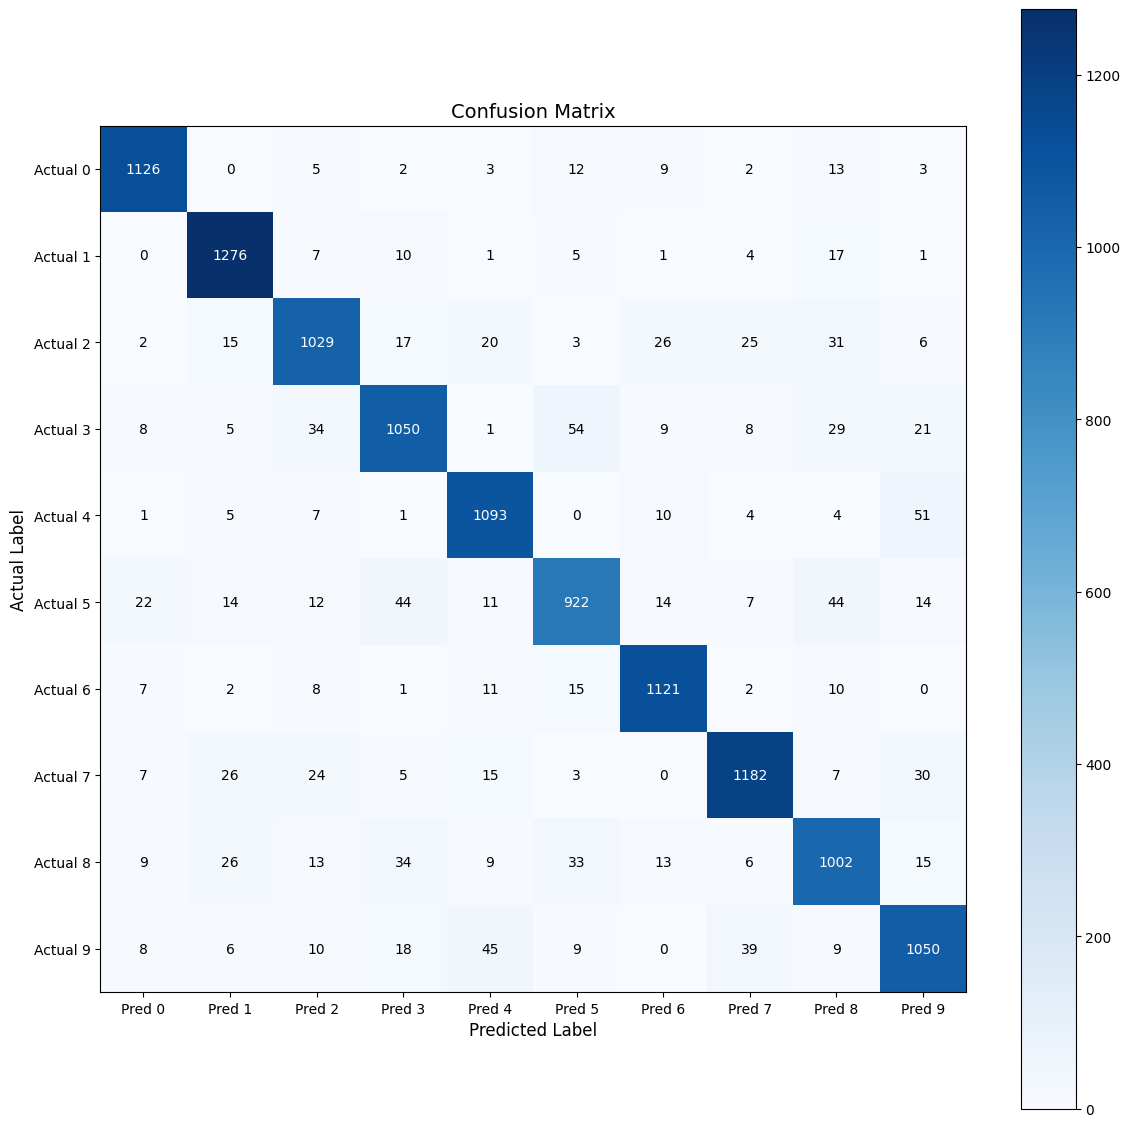

In [12]:
def evaluate_classification(y_true, y_pred):
    cm        = confusion_matrix(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall    = recall_score(y_true, y_pred, average='weighted')
    f1        = f1_score(y_true, y_pred, average='weighted')
    return cm, precision, recall, f1

y_pred_test   = predict_softmax(X_test, W_opt, b_opt)
y_test_labels = np.argmax(y_test, axis=1)
cm, precision, recall, f1 = evaluate_classification(y_test_labels, y_pred_test)

print("\nConfusion Matrix:")
print(cm)
print(f"Precision: {precision:.2f}")
print(f"Recall:    {recall:.2f}")
print(f"F1-Score:  {f1:.2f}")

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(12, 12))
cax = ax.imshow(cm, cmap='Blues')
num_classes = cm.shape[0]
ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels([f'Pred {i}' for i in range(num_classes)])
ax.set_yticklabels([f'Actual {i}' for i in range(num_classes)])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i,j], ha='center', va='center',
                color='white' if cm[i,j] > np.max(cm)/2 else 'black')
ax.grid(False)
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.tight_layout()
plt.colorbar(cax)
plt.show()